In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/march-machine-learning-mania-2026/Conferences.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WNCAATourneyDetailedResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WRegularSeasonCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MNCAATourneySeedRoundSlots.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MGameCities.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WSecondaryTourneyCompactResults.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WGameCities.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/MSeasons.csv
/kaggle/input/competitions/march-machine-learning-mania-2026/WNCAATourneySlots.csv
/kaggle/input/competitions/march-machine-learning

In [2]:
#!pip install requests beautifulsoup4 pandas

# **Introduction**

This notebook is designed to develop a Machine Learning (ML) model that predicts the outcome of NCAA Men’s and Women’s basketball games with a certain probability. The objective is to leverage statistical metrics, feature engineering, and machine learning techniques to create a predictive model for March Madness matchups.

## **Project Steps**
The project will follow these key steps:

1. **Loading Data**  
   - Import necessary CSV files containing historical game results, team statistics, and other relevant datasets.  
   
2. **Incorporating Additional Metrics**  
   - Integrate external data sources, such as advanced efficiency metrics, rankings, and team performance indicators.  

3. **Feature Engineering**  
   - Transform raw data into meaningful features, including:  
     - Pythagorean expectation  
     - ELO ratings  
     - Offensive and defensive efficiencies  
     - Team-specific statistical trends  

4. **Feature Selection**  
   - Identify the most influential features for predicting game outcomes using statistical analysis and feature importance techniques.  

5. **Model Building**  
   - Develop a predictive ML model, testing various algorithms such as logistic regression, random forests, gradient boosting, or neural networks.  

6. **Model Training & Evaluation**  
   - Train the model on past tournament and regular-season data.  
   - Evaluate performance using accuracy, log loss, and other relevant metrics.  

7. **Prediction & Interpretation**  
   - Use the trained model to simulate matchups and generate probabilities for game outcomes.  
   - Analyze model insights and refine based on performance.  

---

## **Data Sources and Methodology**

This project builds upon a previous independent ML study initiated after last year’s tournament. The initial project focused on calculating Pythagorean expectations and ELO ratings to compare teams in head-to-head matchups.

- **Previous Work:**  
  - [March Madness ELO Project](https://github.com/mrprestegaard/MM_Bracket_Predicting_Machine/blob/main/March_Madness_ELO_Project.ipynb)  

- **Additional Data Sources:**  
  - Advanced efficiency metrics were sourced from Bart Torvik’s database.  
  - [Bart Torvik's NCAA Efficiency Ratings](https://barttorvik.com/ncaaw/trank.php)  

This notebook aims to enhance and expand upon these previous methodologies by integrating more sophisticated features and ML techniques to improve prediction accuracy.


In [3]:
# Define the base path for Kaggle input directory
data_path = "/kaggle/input/competitions/march-machine-learning-mania-2026"
# v/kaggle/input/competitions/march-machine-learning-mania-2026/MTeamSpellings.csv
MTeamSpellings = pd.read_csv(f"{data_path}/MTeamSpellings.csv")
#print(MTeamSpellings)
WTeamSpellings = pd.read_csv(f"{data_path}/WTeamSpellings.csv")
#WTeamSpellings
# Load the regular season detailed results
MRegularSeasonDetailedResults = pd.read_csv(f"{data_path}/MRegularSeasonDetailedResults.csv")
# Load the team names for merging later
MTeams = pd.read_csv(f"{data_path}/MTeams.csv")[['TeamID', 'TeamName']]

## **Step 1: Data Loading**
1. Load all the tables from the competition that we will eventually use in this notebook.

## Women's ADvanced Stats from Barttovik.com -- fantastic resource for Offensive and Defensive Efficiency

In [4]:
#!pip install selenium
!pip install webdriver-manager

In [5]:
# Kenpom-LIKE rankings for the women's teams.

import requests
from bs4 import BeautifulSoup
import pandas as pd

# URL of the page with the table
url = "https://barttorvik.com/ncaaw/trank.php"

# Make the HTTP request with a browser-like header
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Referer": url
}

# Start a session
session = requests.Session()

# Step 1: Get the verification page
session.get(url, headers=headers)

# Step 2: Simulate the browser verification form submit
payload = {"js_test_submitted": "1"}
response = session.post(url, headers=headers, data=payload)

# Parse the real page content
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")
if table is None:
    raise ValueError("No table found. The site may have changed its page structure.")

tbody = table.find("tbody")
if tbody is None:
    raise ValueError("No tbody found inside the table.")

# Initialize a list to hold all the row data
rows_data = []

# Iterate through all table rows in the <tbody>
for row in tbody.find_all("tr"):
    # Find all the <td> cells in the row
    cells = row.find_all("td")
    # Extract text from each cell, using a space as a separator in case of multiple text nodes
    row_text = [cell.get_text(separator=" ", strip=True) for cell in cells]
    # Append the cleaned row data if it has content
    if row_text:
        rows_data.append(row_text)

# At this point, rows_data is a list of lists, where each inner list is a row from the table
columns = [
    "Rk", "Team", "Conf", "G", "Rec", "AdjOE", "AdjDE", "Barthag", 
    "EFG%", "EFGD%", "TOR", "TORD", "ORB", "DRB", "FTR", "FTRD", 
    "2P%", "2P%D", "3P%", "3P%D", "3PR", "3PRD", "Adj T.", "WAB"
]

df_barttorvik_womens = pd.DataFrame(rows_data, columns=columns)

# ✅ Apply Manual Fixes Immediately After Data Import
manual_fixes_womens = {
    "Texas A&M Corpus Chris": "texas a&m corpus",
    "Texas A&M Commerce": "east texas a&m",
    "Southeast Missouri St.": "se missouri st.",
    "Mississippi Valley St.": "mississippi valley state",
    "Cal St. Bakersfield": "cal state bakersfield",
    "UT Rio Grande Valley": "UTRGV",
    "Queens": "Queens NC",
    "Saint Francis": "St Francis PA",
}

# Replace team names
df_barttorvik_womens["Team"] = df_barttorvik_womens["Team"].replace(manual_fixes_womens)

# Define the columns to clean
columns_to_clean = [
    'AdjOE', 'AdjDE', 'Barthag', 'EFG%',
    'EFGD%', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P%', '2P%D',
    '3P%', '3P%D', '3PR', '3PRD', 'Adj T.', 'WAB'
]

# Remove anything after the first space in the specified columns
for col in columns_to_clean:
    df_barttorvik_womens[col] = df_barttorvik_womens[col].astype(str).str.split(" ").str[0]

# Convert back to numeric type if applicable
df_barttorvik_womens[columns_to_clean] = df_barttorvik_womens[columns_to_clean].apply(
    pd.to_numeric, errors='coerce'
)

print("Columns cleaned: Extracted only the stats, removed rankings.")
print(df_barttorvik_womens.head())

Columns cleaned: Extracted only the stats, removed rankings.
  Rk                      Team Conf   G   Rec  AdjOE  AdjDE  Barthag  EFG%  \
0  1     Connecticut 1 seed, ✅   BE  34  34-0  128.0   65.2   0.9996  59.7   
1  2            UCLA 1 seed, ✅  B10  32  31-1  133.5   72.4   0.9991  57.2   
2  3           Texas 1 seed, ✅  SEC  34  31-3  125.3   70.1   0.9988  53.2   
3  4  South Carolina 1 seed, ✅  SEC  34  31-3  126.7   71.3   0.9986  55.4   
4  5             LSU 2 seed, ✅  SEC  32  27-5  127.1   74.9   0.9977  54.6   

   EFGD%  ...   FTR  FTRD   2P%  2P%D   3P%  3P%D   3PR  3PRD  Adj T.   WAB  
0   39.3  ...  19.4  20.0  59.8  38.0  39.6  27.4  36.1  44.2    71.8  13.6  
1   41.2  ...  24.0  18.5  57.6  40.5  37.5  28.3  31.5  35.7    66.9  17.8  
2   43.0  ...  29.7  34.8  53.8  42.5  33.9  29.4  19.1  30.0    70.6  15.0  
3   39.8  ...  31.4  17.1  55.3  38.6  37.1  28.1  25.2  34.3    70.2  15.1  
4   40.1  ...  33.4  27.1  53.8  37.9  38.1  29.0  21.5  40.0    75.5   9.4  

[

In [6]:
# # Kenpom-LIKE rankings for the women's teams.

# import requests
# from bs4 import BeautifulSoup
# import pandas as pd

# # URL of the page with the table
# url = "https://barttorvik.com/ncaaw/trank.php#"
# # Make the HTTP request with a browser-like header
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# response = requests.get(url, headers=headers)
# # Parse the page content with BeautifulSoup
# soup = BeautifulSoup(response.text, "html.parser")
# table = soup.find("table")
# tbody = table.find("tbody")

# # Initialize a list to hold all the row data
# rows_data = []
# # Iterate through all table rows in the <tbody>
# for row in tbody.find_all("tr"):
#     # Find all the <td> cells in the row
#     cells = row.find_all("td")
#     # Extract text from each cell, using a space as a separator in case of multiple text nodes
#     row_text = [cell.get_text(separator=" ", strip=True) for cell in cells]
#     # Append the cleaned row data if it has content
#     if row_text:
#         rows_data.append(row_text)

# # At this point, rows_data is a list of lists, where each inner list is a row from the table
# columns = [
#     "Rk", "Team", "Conf", "G", "Rec", "AdjOE", "AdjDE", "Barthag", 
#     "EFG%", "EFGD%", "TOR", "TORD", "ORB", "DRB", "FTR", "FTRD", 
#     "2P%", "2P%D", "3P%", "3P%D", "3PR", "3PRD", "Adj T.", "WAB"
# ]

# df_barttorvik_womens = pd.DataFrame(rows_data, columns=columns)
# # ✅ Apply Manual Fixes Immediately After Data Import
# manual_fixes_womens = {
#     "Texas A&M Corpus Chris": "texas a&m corpus",
#     "Texas A&M Commerce": "east texas a&m",
#     "Southeast Missouri St.": "se missouri st.",
#     "Mississippi Valley St.": "mississippi valley state",
#     "Cal St. Bakersfield": "cal state bakersfield",
#     "UT Rio Grande Valley": "UTRGV",
#     "Queens": "Queens NC",
#     "Saint Francis": "St Francis PA",
# }

# # Replace team names
# df_barttorvik_womens["Team"] = df_barttorvik_womens["Team"].replace(manual_fixes_womens)

# # Define the columns to clean
# columns_to_clean = [
#     'AdjOE', 'AdjDE', 'Barthag', 'EFG%',
#        'EFGD%', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P%', '2P%D',
#        '3P%', '3P%D', '3PR', '3PRD', 'Adj T.', 'WAB'
# ]

# # Remove anything after the first space in the specified columns
# for col in columns_to_clean:
#     df_barttorvik_womens[col] = df_barttorvik_womens[col].astype(str).str.split(" ").str[0]

# # Convert back to numeric type if applicable
# df_barttorvik_womens[columns_to_clean] = df_barttorvik_womens[columns_to_clean].apply(pd.to_numeric, errors='coerce')

# print("Columns cleaned: Extracted only the stats, removed rankings.")
# # ✅ Verify that replacements were applied
# #print(df_barttorvik_womens[df_barttorvik_womens["Team"].isin(manual_fixes_womens.values())])

# # ✅ Print first few rows
# print(df_barttorvik_womens.head())

## Men's Advanced Stats from Barttovik.com -- Fantastic resource for Offensive and Defensive Efficiency

In [7]:
# Kenpom-LIKE rankings for the men's teams.

import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

session = requests.Session()

# ---- Step 1: verify session on women's page first ----
w_url = "https://barttorvik.com/ncaaw/trank.php"
session.get(w_url, headers=headers)
session.post(w_url, headers=headers, data={"js_test_submitted": "1"})

# ---- Step 2: use same verified session for men's page ----
url = "https://barttorvik.com/ncaam/trank.php"
response = session.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")
if table is None:
    raise ValueError("No table found on men's page.")

tbody = table.find("tbody")
if tbody is None:
    raise ValueError("No tbody found on men's page.")

rows_data = []
for row in tbody.find_all("tr"):
    # Find all the <td> cells in the row
    cells = row.find_all("td")
    # Extract text from each cell, using a space as a separator in case of multiple text nodes
    row_text = [cell.get_text(separator=" ", strip=True) for cell in cells]
    # Append the cleaned row data if it has content
    if row_text:
        rows_data.append(row_text)

columns = [
    "Rk", "Team", "Conf", "G", "Rec", "AdjOE", "AdjDE", "Barthag", 
    "EFG%", "EFGD%", "TOR", "TORD", "ORB", "DRB", "FTR", "FTRD", 
    "2P%", "2P%D", "3P%", "3P%D", "3PR", "3PRD", "Adj T.", "WAB"
]

df_barttorvik_mens = pd.DataFrame(rows_data, columns=columns)

# ✅ Apply Manual Fixes Immediately After Data Import
manual_fixes_mens = {
    "Santa Clara (H) 151 UC Riverside": "Santa Clara",
    "Stanford (H) 128 Cal St. Northridge": "Stanford",
    "Oklahoma St. (H) 139 Wichita St.": "Oklahoma St",
    "Georgia Tech (H) 133 Jacksonville St.": "Georgia Tech",
    "St. Bonaventure (H) 127 Kent St.": "St Bonaventure",
    "Arkansas St. (H) 108 Saint Louis": "Arkansas St",
    "Saint Louis (A) 95 Arkansas St.": "St Louis",
    "Middle Tennessee (H) 135 Chattanooga": "MTSU",
    "Kent St. (A) 92 St. Bonaventure": "Kent",
    "Cal St. Northridge (A) 75 Stanford": "CS Northridge",
    "Jacksonville St. (A) 90 Georgia Tech": "Jacksonville St",
    "Chattanooga (A) 120 Middle Tennessee": "Chattanooga",
    "Wichita St. (A) 87 Oklahoma St.": "Wichita St",
    "Texas A&M Corpus Chris": "a&m corpus christi",
    "Texas A&M Commerce": "East Texas A&M",
    "Southeast Missouri St.": "se missouri st.",
    "Mississippi Valley St.": "mississippi valley state",
    "Cal St. Bakersfield": "cal state bakersfield",
    "UT Rio Grande Valley": "UTRGV",
    "Saint Francis 16 seed, ❌": "St Francis PA",
    "150  UC Riverside (A) 51 Santa Clara": "uc riverside",
    "Queens": "queens nc",
}

# Replace team names
df_barttorvik_mens["Team"] = df_barttorvik_mens["Team"].replace(manual_fixes_mens)

# ✅ Verify that replacements were applied
# print(df_barttorvik_mens[df_barttorvik_mens["Team"].isin(manual_fixes_mens.values())])

# Define the columns to clean
columns_to_clean = [
    'AdjOE', 'AdjDE', 'Barthag', 'EFG%',
    'EFGD%', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P%', '2P%D',
    '3P%', '3P%D', '3PR', '3PRD', 'Adj T.', 'WAB'
]

# Remove anything after the first space in the specified columns
for col in columns_to_clean:
    df_barttorvik_mens[col] = df_barttorvik_mens[col].astype(str).str.split(" ").str[0]

# Convert back to numeric type if applicable
df_barttorvik_mens[columns_to_clean] = df_barttorvik_mens[columns_to_clean].apply(
    pd.to_numeric, errors='coerce'
)

print("Columns cleaned: Extracted only the stats, removed rankings.")

# ✅ Print first few rows
print(df_barttorvik_mens.head())

Columns cleaned: Extracted only the stats, removed rankings.
  Rk                Team Conf   G   Rec  AdjOE  AdjDE  Barthag  EFG%  EFGD%  \
0  1      Duke 1 seed, ✅  ACC  34  32-2  128.1   90.7   0.9815  56.8   46.2   
1  2  Michigan 1 seed, ✅  B10  34  31-3  127.6   90.9   0.9801  58.1   44.7   
2  3   Arizona 1 seed, ✅  B12  34  32-2  126.8   91.3   0.9777  55.1   45.0   
3  4   Florida 1 seed, ✅  SEC  33  26-7  126.0   92.2   0.9733  53.5   46.3   
4  5   Houston 2 seed, ✅  B12  34  28-6  125.2   92.3   0.9710  52.1   46.6   

   ...   FTR  FTRD   2P%  2P%D   3P%  3P%D   3PR  3PRD  Adj T.   WAB  
0  ...  37.8  23.7  60.1  46.6  35.1  30.4  44.4  45.7    65.8  13.6  
1  ...  37.7  26.3  61.0  44.3  36.0  30.2  41.8  41.8    71.2  14.0  
2  ...  42.9  27.7  55.4  43.8  36.0  31.4  26.8  37.2    70.0  13.6  
3  ...  39.1  34.0  57.9  45.2  30.8  32.4  37.1  33.7    70.4   8.5  
4  ...  26.9  39.0  51.9  45.5  34.9  32.1  40.8  40.9    63.3   8.9  

[5 rows x 24 columns]


In [8]:
# # URL of the page with the table
# url = "https://barttorvik.com/ncaam/trank.php#"
# headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
# response = requests.get(url, headers=headers)
# soup = BeautifulSoup(response.text, "html.parser")
# table = soup.find("table")
# tbody = table.find("tbody")

# rows_data = []
# for row in tbody.find_all("tr"):
#     # Find all the <td> cells in the row
#     cells = row.find_all("td")
#     # Extract text from each cell, using a space as a separator in case of multiple text nodes
#     row_text = [cell.get_text(separator=" ", strip=True) for cell in cells]
#     # Append the cleaned row data if it has content
#     if row_text:
#         rows_data.append(row_text)
# columns = [
#     "Rk", "Team", "Conf", "G", "Rec", "AdjOE", "AdjDE", "Barthag", 
#     "EFG%", "EFGD%", "TOR", "TORD", "ORB", "DRB", "FTR", "FTRD", 
#     "2P%", "2P%D", "3P%", "3P%D", "3PR", "3PRD", "Adj T.", "WAB"
# ]
# df_barttorvik_mens = pd.DataFrame(rows_data, columns=columns)
# # ✅ Apply Manual Fixes Immediately After Data Import
# manual_fixes_mens = {
#     "Santa Clara (H) 151 UC Riverside": "Santa Clara",
#     "Stanford (H) 128 Cal St. Northridge": "Stanford",
#     "Oklahoma St. (H) 139 Wichita St.": "Oklahoma St",
#     "Georgia Tech (H) 133 Jacksonville St.": "Georgia Tech",
#     "St. Bonaventure (H) 127 Kent St.": "St Bonaventure",
#     "Arkansas St. (H) 108 Saint Louis": "Arkansas St",
#     "Saint Louis (A) 95 Arkansas St.": "St Louis",
#     "Middle Tennessee (H) 135 Chattanooga": "MTSU",
#     "Kent St. (A) 92 St. Bonaventure": "Kent",
#     "Cal St. Northridge (A) 75 Stanford": "CS Northridge",
#     "Jacksonville St. (A) 90 Georgia Tech": "Jacksonville St",
#     "Chattanooga (A) 120 Middle Tennessee": "Chattanooga",
#     "Wichita St. (A) 87 Oklahoma St.": "Wichita St",
#     "Texas A&M Corpus Chris": "a&m corpus christi",
#     "Texas A&M Commerce": "East Texas A&M",
#     "Southeast Missouri St.": "se missouri st.",
#     "Mississippi Valley St.": "mississippi valley state",
#     "Cal St. Bakersfield": "cal state bakersfield",
#     "UT Rio Grande Valley": "UTRGV",
#     "Saint Francis 16 seed, ❌": "St Francis PA",
#     "150  UC Riverside (A) 51 Santa Clara": "uc riverside",
#     "Queens": "queens nc",
# }

# # Replace team names
# df_barttorvik_mens["Team"] = df_barttorvik_mens["Team"].replace(manual_fixes_mens)

# # ✅ Verify that replacements were applied
# #print(df_barttorvik_mens[df_barttorvik_mens["Team"].isin(manual_fixes_mens.values())])

# # Define the columns to clean
# columns_to_clean = [
#     'AdjOE', 'AdjDE', 'Barthag', 'EFG%',
#        'EFGD%', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P%', '2P%D',
#        '3P%', '3P%D', '3PR', '3PRD', 'Adj T.', 'WAB'
# ]

# # Remove anything after the first space in the specified columns
# for col in columns_to_clean:
#     df_barttorvik_mens[col] = df_barttorvik_mens[col].astype(str).str.split(" ").str[0]

# # Convert back to numeric type if applicable
# df_barttorvik_mens[columns_to_clean] = df_barttorvik_mens[columns_to_clean].apply(pd.to_numeric, errors='coerce')

# print("Columns cleaned: Extracted only the stats, removed rankings.")

# # ✅ Print first few rows
# print(df_barttorvik_mens.head())

In [9]:
import pandas as pd
from fuzzywuzzy import process, fuzz

def clean_and_match_with_spellings(df_barttorvik, df_team_spellings):
    """Matches teams using a team spellings table for better accuracy."""

    # **Step 1: Extract Only Team Names**
    df_barttorvik["Clean_Team"] = df_barttorvik["Team"].str.extract(r'^([A-Za-z&.\s\'-]+?)(?=\s*\(\w\)|\s+\d|\s+seed|$)')[0].str.strip()

    # **Step 2: Remove "seed" if present**
    df_barttorvik["Clean_Team"] = df_barttorvik["Clean_Team"].str.replace(r"\bseed\b", "", regex=True).str.strip()

    # **Step 3: Ensure No `None` Values**
    df_barttorvik["Clean_Team"] = df_barttorvik["Clean_Team"].fillna("UNKNOWN")

    # **Step 4: Merge with Team Spellings for Exact Matches**
    df_final = df_barttorvik.merge(df_team_spellings, left_on="Clean_Team", right_on="TeamNameSpelling", how="left")

    # **Step 5: Identify Unmatched Teams**
    unmatched_teams = df_final[df_final["TeamID"].isna()]["Clean_Team"].dropna().tolist()

    # **Step 6: Apply Fuzzy Matching Only for Remaining Unmatched Teams**
    if unmatched_teams:
        df_spellings_list = df_team_spellings["TeamNameSpelling"].tolist()

        def get_best_match(team_name, team_list):
            if team_name in team_list:  # Exact match
                return team_name
            match, score = process.extractOne(team_name, team_list, scorer=fuzz.token_sort_ratio)
            return match if score > 90 else None  # Lower threshold slightly for better matches

        fuzzy_matches = {team: get_best_match(team, df_spellings_list) for team in unmatched_teams}

        # Apply fuzzy matches
        df_barttorvik["Clean_Team"] = df_barttorvik["Clean_Team"].replace(fuzzy_matches)

    # **Step 7: Re-Merge After Fuzzy Matching**
    df_final = df_barttorvik.merge(df_team_spellings, left_on="Clean_Team", right_on="TeamNameSpelling", how="left")

    # **Step 8: Check for Any Remaining Unmatched Teams**
    still_unmatched = df_final[df_final["TeamID"].isna()]["Clean_Team"].dropna().tolist()
    print("Still Unmatched Teams:", still_unmatched)

    return df_final

# **Run the Function Again After Fixing `Clean_Team` Extraction**
df_final_mens = clean_and_match_with_spellings(df_barttorvik_mens, MTeamSpellings)
df_final_womens = clean_and_match_with_spellings(df_barttorvik_womens, WTeamSpellings)

# **Manually Fix Known Mismatches**
df_final_womens.loc[df_final_womens["Team"] == "texas a&m corpus", "TeamID"] = 3394
df_final_womens.loc[df_final_womens["Team"] == "east texas a&m", "TeamID"] = 3477
df_final_mens.loc[df_final_mens["Team"] == "a&m corpus christi", "TeamID"] = 1394
df_final_mens.loc[df_final_mens["Team"] == "East Texas A&M", "TeamID"] = 1477
df_final_mens.loc[df_final_mens["Team"] == "UC Riverside (A) 51 Santa Clara", "TeamID"] = 1415
df_final_mens.loc[df_final_mens["Team"] == "Saint Francis", "TeamID"] = 1384
df_final_mens.loc[df_final_mens["Clean_Team"] == "Queens", "TeamID"] = 1474


# **Check Remaining Unmatched Teams**
unmatched_womens_df = df_final_womens[df_final_womens["TeamID"].isna()][["Team"]]
unmatched_mens_df = df_final_mens[df_final_mens["TeamID"].isna()][["Team"]]
print("Unmatched Women's Teams After Processing:\n", unmatched_womens_df)
print("Unmatched Men's Teams After Processing:\n", unmatched_mens_df)

/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Still Unmatched Teams: []
Still Unmatched Teams: []
Unmatched Women's Teams After Processing:
 Empty DataFrame
Columns: [Team]
Index: []
Unmatched Men's Teams After Processing:
                   Team
199  Queens 15 seed, ✅


In [10]:
pd.set_option('display.max_rows', None)
# Print all TeamIDs
#print(df_final_mens[['Team', 'Clean_Team','TeamID']])
pd.set_option('display.max_rows', 30)

---
# **MEN's Statistics and Calculations**

## **ELO Rating System Calcalution**

In [11]:
# Define the Elo update function
def update_elo(winner_elo, loser_elo, K=20):
    expected_win = 1 / (1 + 10 ** ((loser_elo - winner_elo) / 400))
    new_winner_elo = winner_elo + K * (1 - expected_win)
    new_loser_elo = loser_elo - K * (1 - expected_win)
    return new_winner_elo, new_loser_elo

# Initialize DataFrame to store Elo ratings for all years
all_years_elo = pd.DataFrame(columns=['Year', 'TeamID', 'Elo'])

# Loop through years from 2003 to 2026
for year in range(2003, 2027):
    # Filter games for the specific year
    games = MRegularSeasonDetailedResults[MRegularSeasonDetailedResults['Season'] == year][['DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore']].copy()
    games.sort_values(by="DayNum", inplace=True)

    # Initialize Elo ratings for the teams that played that year
    unique_teams = pd.concat([games['WTeamID'], games['LTeamID']]).unique()
    elo_dict = {team: 1500 for team in unique_teams}

    # Calculate Elo ratings for that year
    for _, game in games.iterrows():
        w_elo = elo_dict[game['WTeamID']]
        l_elo = elo_dict[game['LTeamID']]

        new_w_elo, new_l_elo = update_elo(w_elo, l_elo)

        elo_dict[game['WTeamID']] = new_w_elo
        elo_dict[game['LTeamID']] = new_l_elo

    # Convert yearly Elo dictionary to DataFrame
    year_elo_df = pd.DataFrame(list(elo_dict.items()), columns=['TeamID', 'Elo'])
    year_elo_df['Year'] = year
    all_years_elo = pd.concat([all_years_elo, year_elo_df], ignore_index=True)

# Merge with team names
all_years_elo = pd.merge(all_years_elo, MTeams, on='TeamID', how='left')

# Rearrange columns
all_years_elo = all_years_elo[['Year', 'TeamID', 'TeamName', 'Elo']]


/tmp/ipykernel_109/1012677155.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_years_elo = pd.concat([all_years_elo, year_elo_df], ignore_index=True)


In [12]:
all_years_elo

,Year,TeamID,TeamName,Elo
0,2003,1104,Alabama,1542.270147
1,2003,1272,Memphis,1630.639219
2,2003,1266,Marquette,1641.725417
3,2003,1296,N Illinois,1528.984888
4,2003,1458,Wisconsin,1614.128280
...,...,...,...,...
8341,2026,1411,TX Southern,1437.101478
8342,2026,1351,Rider,1346.119658
8343,2026,1316,North Florida,1360.564103
8344,2026,1205,Gardner Webb,1322.949592


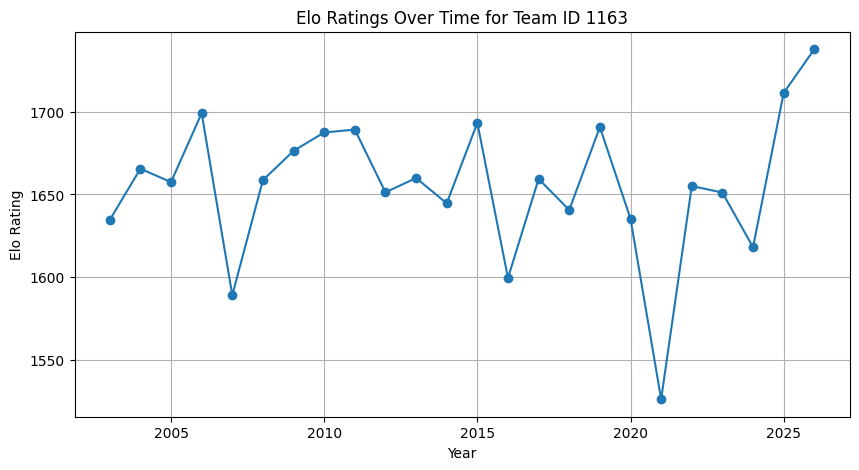

In [13]:
import matplotlib.pyplot as plt

# Filter the DataFrame for Team ID 1163
team_1163_elo = all_years_elo[all_years_elo['TeamID'] == 1181]
# Ensure the Year column is sorted, just in case
team_1163_elo = team_1163_elo.sort_values(by='Year')

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(team_1163_elo['Year'], team_1163_elo['Elo'], marker='o', linestyle='-')
plt.title('Elo Ratings Over Time for Team ID 1163')
plt.xlabel('Year')
plt.ylabel('Elo Rating')
plt.grid(True)
plt.show()

In [14]:
# Filter the DataFrame for the year 2024 and sort by Elo in descending order
M_elo_2026 = all_years_elo[all_years_elo['Year'] == 2026].sort_values(by='Elo', ascending=False)
# Display the top 10 Elo values for 2024
print(M_elo_2026)

      Year TeamID      TeamName          Elo
8098  2026   1181          Duke  1737.928272
8044  2026   1112       Arizona  1731.985684
8026  2026   1276      Michigan  1716.413996
8059  2026   1211       Gonzaga  1690.720980
7998  2026   1438      Virginia  1686.539174
...    ...    ...           ...          ...
8344  2026   1205  Gardner Webb  1322.949592
8330  2026   1442    W Illinois  1317.797098
8319  2026   1419           ULM  1317.392722
8338  2026   1282   Missouri KC  1302.578453
8345  2026   1290  MS Valley St  1293.566470

[365 rows x 4 columns]


In [15]:
# Create a DataFrame for winners' and losers' points separately
df_winners = MRegularSeasonDetailedResults[['Season', 'WTeamID', 'WScore', 'LScore']].rename(
    columns={'WTeamID': 'TeamID', 'WScore': 'PointsScored', 'LScore': 'PointsAllowed'}
)

df_losers = MRegularSeasonDetailedResults[['Season', 'LTeamID', 'LScore', 'WScore']].rename(
    columns={'LTeamID': 'TeamID', 'LScore': 'PointsScored', 'WScore': 'PointsAllowed'}
)

# Combine winners and losers into one DataFrame
df_scores = pd.concat([df_winners, df_losers], ignore_index=True)

# Aggregate total points scored and allowed by each team across all seasons
df_aggregated = df_scores.groupby(['TeamID', 'Season']).agg(
    TotalPointsScored=pd.NamedAgg(column='PointsScored', aggfunc='sum'),
    TotalPointsAllowed=pd.NamedAgg(column='PointsAllowed', aggfunc='sum')
).reset_index()

# Calculate the Pythagorean Expectation
df_aggregated['PythgExpect'] = (df_aggregated['TotalPointsScored'] ** 13.91) / (
    (df_aggregated['TotalPointsScored'] ** 13.91) + (df_aggregated['TotalPointsAllowed'] ** 13.91)
)

# Merge with team names
df_aggregated = pd.merge(df_aggregated, MTeams, on='TeamID', how='left')

# Add 'Seed' column (set to None initially)
df_aggregated['Seed'] = None

# Reorder the columns to match your original format
MNCAATourneySeedsWithPythagExpect = df_aggregated[['Season', 'Seed', 'TeamID', 'TeamName', 'PythgExpect']]


MNCAATourneySeedsWithPythagExpect

,Season,Seed,TeamID,TeamName,PythgExpect
0,2014,None,1101,Abilene Chr,0.045249
1,2015,None,1101,Abilene Chr,0.092916
2,2016,None,1101,Abilene Chr,0.227800
3,2017,None,1101,Abilene Chr,0.280347
4,2018,None,1101,Abilene Chr,0.397345
...,...,...,...,...,...
8341,2025,None,1479,Mercyhurst,0.230200
8342,2026,None,1479,Mercyhurst,0.479374
8343,2025,None,1480,West Georgia,0.108699
8344,2026,None,1480,West Georgia,0.284406


In [16]:
# Sort by decreasing Pythagorean Expectation
MNCAATourneySeedsWithPythagExpect = MNCAATourneySeedsWithPythagExpect.sort_values(
    by='PythgExpect', ascending=False)
MNCAATourneySeedsWithPythagExpect[MNCAATourneySeedsWithPythagExpect['Season']== 2026]

,Season,Seed,TeamID,TeamName,PythgExpect
1781,2026,None,1181,Duke,0.975489
2490,2026,None,1211,Gonzaga,0.971777
3011,2026,None,1235,Iowa St,0.959509
3978,2026,None,1276,Michigan,0.959092
252,2026,None,1112,Arizona,0.958068
...,...,...,...,...,...
1380,2026,None,1164,Coppin St,0.038516
4122,2026,None,1282,Missouri KC,0.036649
36,2026,None,1102,Air Force,0.025847
2346,2026,None,1205,Gardner Webb,0.022883


In [17]:
# Load the regular season results
df_conferences = pd.read_csv(f"{data_path}/MTeamConferences.csv")
df_conferences[df_conferences['Season'] == 2026]
df_conf_26_M = df_conferences[df_conferences['Season'] == 2026]
df_conf_26_M.shape

(365, 3)

In [18]:
M_elo_2026


,Year,TeamID,TeamName,Elo
8098,2026,1181,Duke,1737.928272
8044,2026,1112,Arizona,1731.985684
8026,2026,1276,Michigan,1716.413996
8059,2026,1211,Gonzaga,1690.720980
7998,2026,1438,Virginia,1686.539174
...,...,...,...,...
8344,2026,1205,Gardner Webb,1322.949592
8330,2026,1442,W Illinois,1317.797098
8319,2026,1419,ULM,1317.392722
8338,2026,1282,Missouri KC,1302.578453


In [19]:
M_elo_2026.to_csv("ELo_Scores_Mens_2026.csv")

In [20]:
df_conf_26_M

,Season,TeamID,ConfAbbrev
13388,2026,1101,wac
13389,2026,1102,mwc
13390,2026,1103,mac
13391,2026,1104,sec
13392,2026,1105,swac
...,...,...,...
13748,2026,1477,southland
13749,2026,1478,nec
13750,2026,1479,nec
13751,2026,1480,a_sun


In [21]:
# Merge 2026 men's Elo Ratings with Conference Data
df_conf_26_M = pd.merge(M_elo_2026, df_conf_26_M, on='TeamID', how='inner')

# Calculate the average Elo rating per conference
conference_strength_M = df_conf_26_M.groupby('ConfAbbrev')['Elo'].mean().reset_index()

# Sort conferences by average Elo in descending order
conference_strength_M = conference_strength_M.sort_values(by='Elo', ascending=False)

# Display the results
print(conference_strength_M.head(30))  

    ConfAbbrev          Elo
9   big_twelve  1566.673734
3          acc  1559.871456
23         sec  1557.850419
8      big_ten  1556.044831
5     big_east  1543.882054
1        a_ten  1528.136420
19         mwc  1524.319347
30         wcc  1520.176595
18         mvc  1511.120059
2          aac  1507.905402
29         wac  1503.817779
11         caa  1503.701624
16         mac  1498.496870
14         ivy  1496.634106
12        cusa  1494.612033
10    big_west  1493.017902
27    sun_belt  1492.581332
15        maac  1486.254187
13     horizon  1480.367020
25   southland  1474.798154
7    big_south  1473.784796
24    southern  1473.435831
6      big_sky  1472.002218
21         ovc  1467.232887
26      summit  1466.427964
0        a_sun  1462.179777
22     patriot  1460.662414
20         nec  1446.123319
4          aec  1439.832501
28        swac  1433.523342


---
# **WOMEN's Statistics and Calculations**


In [22]:
# Define the base path for Kaggle input directory
data_path = "/kaggle/input/competitions/march-machine-learning-mania-2026"

# Load the regular season detailed results
WRegularSeasonDetailedResults = pd.read_csv(f"{data_path}/WRegularSeasonDetailedResults.csv")

# Load the team names for merging later
WTeams = pd.read_csv(f"{data_path}/WTeams.csv")[['TeamID', 'TeamName']]

# Define the Elo update function
def update_elo(winner_elo, loser_elo, K=20):
    expected_win = 1 / (1 + 10 ** ((loser_elo - winner_elo) / 400))
    new_winner_elo = winner_elo + K * (1 - expected_win)
    new_loser_elo = loser_elo - K * (1 - expected_win)
    return new_winner_elo, new_loser_elo

# Initialize DataFrame to store Elo ratings for all years
all_years_elo_w = pd.DataFrame(columns=['Year', 'TeamID', 'Elo'])

# Loop through years from 2003 to 2026
for year in range(2003, 2027):
    # Filter games for the specific year
    games = WRegularSeasonDetailedResults[WRegularSeasonDetailedResults['Season'] == year][['DayNum', 'WTeamID', 'LTeamID', 'WScore', 'LScore']].copy()
    
    if games.empty:
        print(f"No data for year {year}")
        continue  # Skip years without data

    games.sort_values(by="DayNum", inplace=True)

    # Initialize Elo ratings for the teams that played that year
    unique_teams = pd.concat([games['WTeamID'], games['LTeamID']]).unique()
    elo_dict = {team: 1500 for team in unique_teams}

    # Calculate Elo ratings for that year
    for _, game in games.iterrows():
        w_elo = elo_dict[game['WTeamID']]
        l_elo = elo_dict[game['LTeamID']]

        new_w_elo, new_l_elo = update_elo(w_elo, l_elo)

        elo_dict[game['WTeamID']] = new_w_elo
        elo_dict[game['LTeamID']] = new_l_elo

    # Convert yearly Elo dictionary to DataFrame
    year_elo_df = pd.DataFrame(list(elo_dict.items()), columns=['TeamID', 'Elo'])
    year_elo_df['Year'] = year
    
    # Append to the main DataFrame
    all_years_elo_w = pd.concat([all_years_elo_w, year_elo_df], ignore_index=True)

# Check if Elo table has data before merging
print(f"Total teams in Elo ratings: {all_years_elo_w.shape[0]}")

# Merge with team names
all_years_elo_w = pd.merge(all_years_elo_w, WTeams, on='TeamID', how='left')

# Rearrange columns
all_years_elo_w = all_years_elo_w[['Year', 'TeamID', 'TeamName', 'Elo']]

# Display the DataFrame
print(all_years_elo_w.head(10))  # Check if data is present

No data for year 2003
No data for year 2004
No data for year 2005
No data for year 2006
No data for year 2007
No data for year 2008
No data for year 2009


/tmp/ipykernel_109/1065284278.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_years_elo_w = pd.concat([all_years_elo_w, year_elo_df], ignore_index=True)


Total teams in Elo ratings: 5965
   Year TeamID        TeamName          Elo
0  2010   3103           Akron  1536.212967
1  2010   3104         Alabama  1462.367649
2  2010   3110   American Univ  1544.099636
3  2010   3111  Appalachian St  1552.163451
4  2010   3119            Army  1425.468162
5  2010   3120          Auburn  1502.902614
6  2010   3280  Mississippi St  1559.520107
7  2010   3282     Missouri KC  1496.262833
8  2010   3286      Montana St  1514.918514
9  2010   3293       Murray St  1451.549254


In [23]:
data_path = "/kaggle/input/competitions/march-machine-learning-mania-2026"

# Load the regular season results
WRegularSeasonDetailedResults = pd.read_csv(f"{data_path}/WRegularSeasonDetailedResults.csv")

# Load the team names
WTeams = pd.read_csv(f"{data_path}/WTeams.csv")[['TeamID', 'TeamName']]

# Create a DataFrame for winners' and losers' points separately
df_winners = WRegularSeasonDetailedResults[['Season', 'WTeamID', 'WScore', 'LScore']].rename(
    columns={'WTeamID': 'TeamID', 'WScore': 'PointsScored', 'LScore': 'PointsAllowed'}
)

df_losers = WRegularSeasonDetailedResults[['Season', 'LTeamID', 'LScore', 'WScore']].rename(
    columns={'LTeamID': 'TeamID', 'LScore': 'PointsScored', 'WScore': 'PointsAllowed'}
)

# Combine winners and losers into one DataFrame
df_scores = pd.concat([df_winners, df_losers], ignore_index=True)

# Aggregate total points scored and allowed by each team across all seasons
df_aggregated = df_scores.groupby(['TeamID', 'Season']).agg(
    TotalPointsScored=pd.NamedAgg(column='PointsScored', aggfunc='sum'),
    TotalPointsAllowed=pd.NamedAgg(column='PointsAllowed', aggfunc='sum')
).reset_index()

# Calculate the Pythagorean Expectation
df_aggregated['PythgExpect'] = (df_aggregated['TotalPointsScored'] ** 13.91) / (
    (df_aggregated['TotalPointsScored'] ** 13.91) + (df_aggregated['TotalPointsAllowed'] ** 13.91)
)

# Merge with team names
df_aggregated = pd.merge(df_aggregated, WTeams, on='TeamID', how='left')

# Add 'Seed' column (set to None initially)
df_aggregated['Seed'] = None

# Reorder the columns to match your original format
WNCAATourneySeedsWithPythagExpect = df_aggregated[['Season', 'Seed', 'TeamID', 'TeamName', 'PythgExpect']]


WNCAATourneySeedsWithPythagExpect

,Season,Seed,TeamID,TeamName,PythgExpect
0,2014,None,3101,Abilene Chr,0.504322
1,2015,None,3101,Abilene Chr,0.627848
2,2016,None,3101,Abilene Chr,0.885264
3,2017,None,3101,Abilene Chr,0.803124
4,2018,None,3101,Abilene Chr,0.351771
...,...,...,...,...,...
5960,2025,None,3479,Mercyhurst,0.166499
5961,2026,None,3479,Mercyhurst,0.139735
5962,2025,None,3480,West Georgia,0.253491
5963,2026,None,3480,West Georgia,0.528701


In [24]:
# Sort by decreasing Pythagorean Expectation
WNCAATourneySeedsWithPythagExpect = WNCAATourneySeedsWithPythagExpect.sort_values(
    by='PythgExpect', ascending=False
)

WNCAATourneySeedsWithPythagExpect[WNCAATourneySeedsWithPythagExpect['Season']== 2026].head(10)

,Season,Seed,TeamID,TeamName,PythgExpect
946,2026,None,3163,Connecticut,0.999621
2579,2026,None,3261,LSU,0.997806
4865,2026,None,3400,Texas,0.996460
5154,2026,None,3417,UCLA,0.996237
4461,2026,None,3376,South Carolina,0.996092
4780,2026,None,3395,TCU,0.988518
1453,2026,None,3193,Fairfield,0.985378
2829,2026,None,3276,Michigan,0.981107
3135,2026,None,3295,N Dakota St,0.978703
2511,2026,None,3257,Louisville,0.978443


In [25]:
# Load the regular season results
df_conferences = pd.read_csv(f"{data_path}/WTeamConferences.csv")
df_conf_26_W = df_conferences[df_conferences['Season'] == 2026]
df_conf_26_W.shape
# Filter the DataFrame for the year 2024 and sort by Elo in descending order
womens_elo_26 = all_years_elo_w[all_years_elo_w['Year'] == 2026].sort_values(by='Elo', ascending=False)
# Display the top 10 Elo values for 2024
print(womens_elo_26)

# Merge 2026 Women's Elo Ratings with Conference Data
df_conf_elo_26_W = pd.merge(womens_elo_26, df_conf_26_W, on='TeamID', how='inner')

# Calculate the average Elo rating per conference
conference_strength_W = df_conf_elo_26_W.groupby('ConfAbbrev')['Elo'].mean().reset_index()

# Sort conferences by average Elo in descending order
conference_strength_W = conference_strength_W.sort_values(by='Elo', ascending=False)

# Display the results
print(conference_strength_W.head(20))  # Show the top 20 strongest women's conferences

      Year TeamID        TeamName          Elo
5700  2026   3163     Connecticut  1746.230818
5619  2026   3417            UCLA  1739.130903
5624  2026   3400           Texas  1722.990134
5630  2026   3376  South Carolina  1721.897009
5741  2026   3395             TCU  1680.343276
...    ...    ...             ...          ...
5964  2026   3441      W Carolina  1307.617851
5957  2026   3342    Presbyterian  1301.907938
5881  2026   3468      Bellarmine  1296.361029
5963  2026   3434      Valparaiso  1278.770037
5962  2026   3341    Prairie View  1274.543632

[363 rows x 4 columns]
    ConfAbbrev          Elo
23         sec  1589.370725
8      big_ten  1565.891866
9   big_twelve  1561.288145
3          acc  1536.294834
5     big_east  1532.166987
14         ivy  1520.703098
1        a_ten  1518.135163
27    sun_belt  1508.193350
4          aec  1506.296591
2          aac  1501.674805
30         wcc  1499.654742
29         wac  1498.584074
19         mwc  1496.329768
12        cusa  1493

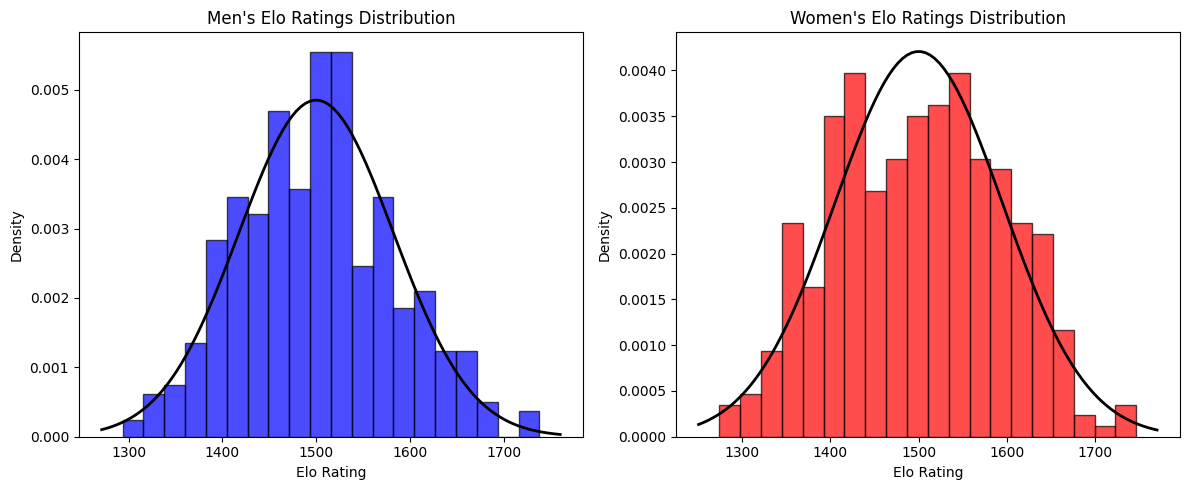

Kolmogorov-Smirnov Test Results:
Men's Elo Distribution: KstestResult(statistic=np.float64(0.03488714868005316), pvalue=np.float64(0.7523470278979875), statistic_location=np.float64(1532.3147255232698), statistic_sign=np.int8(1))
Women's Elo Distribution: KstestResult(statistic=np.float64(0.05184894295649478), pvalue=np.float64(0.2737124255670276), statistic_location=np.float64(1439.6455630095686), statistic_sign=np.int8(1))


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Define the base path for Kaggle input directory

# Load team conference affiliations
df_conferences_m = pd.read_csv(f"{data_path}/MTeamConferences.csv")
df_conferences_w = pd.read_csv(f"{data_path}/WTeamConferences.csv")

# Load Elo ratings for 2025 (Ensure these DataFrames exist in your notebook)
mens_elo_26 = all_years_elo[all_years_elo['Year'] == 2026].copy()
womens_elo_26 = all_years_elo_w[all_years_elo_w['Year'] == 2026].copy()

# Merge Men's Elo Ratings with Conference Data
df_conf_26_M = pd.merge(mens_elo_26, df_conferences_m[df_conferences_m['Season'] == 2026], on='TeamID', how='inner')

# Merge Women's Elo Ratings with Conference Data
df_conf_26_W = pd.merge(womens_elo_26, df_conferences_w[df_conferences_w['Season'] == 2026], on='TeamID', how='inner')

# Extract Elo ratings for men's and women's teams
elo_mens = df_conf_26_M['Elo']
elo_womens = df_conf_26_W['Elo']

# Plot histograms to visualize distributions
plt.figure(figsize=(12, 5))

# Men's Elo distribution
plt.subplot(1, 2, 1)
plt.hist(elo_mens, bins=20, alpha=0.7, color='blue', edgecolor='black', density=True)
mu_m, std_m = stats.norm.fit(elo_mens)  # Fit normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_m, std_m)
plt.plot(x, p, 'k', linewidth=2)
plt.title("Men's Elo Ratings Distribution")
plt.xlabel("Elo Rating")
plt.ylabel("Density")

# Women's Elo distribution
plt.subplot(1, 2, 2)
plt.hist(elo_womens, bins=20, alpha=0.7, color='red', edgecolor='black', density=True)
mu_w, std_w = stats.norm.fit(elo_womens)  # Fit normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu_w, std_w)
plt.plot(x, p, 'k', linewidth=2)
plt.title("Women's Elo Ratings Distribution")
plt.xlabel("Elo Rating")
plt.ylabel("Density")

# Show plots
plt.tight_layout()
plt.show()

# Conduct normality tests (Kolmogorov-Smirnov Test)
ks_mens = stats.kstest(elo_mens, 'norm', args=(mu_m, std_m))
ks_womens = stats.kstest(elo_womens, 'norm', args=(mu_w, std_w))

# Display test results
print("Kolmogorov-Smirnov Test Results:")
print("Men's Elo Distribution:", ks_mens)
print("Women's Elo Distribution:", ks_womens)

## Would you say these are normally distributed based on the Kolmogroc-Smirnov Tests?

- Kolmogorov-Smirnov Test Results:
- Yes — based on those results, both distributions are consistent with being normally distributed.

- How to interpret the Kolmogorov–Smirnov results

- The KS test evaluates:

- Null hypothesis (H₀): The sample comes from the specified distribution (here, normal).

- Alternative hypothesis (H₁): The sample does not come from that distribution.

- You reject H₀ if the p-value < chosen significance level (commonly 0.05).

- Your results
- Distribution	KS Statistic	p-value	Interpretation
- Men's Elo	0.0349	0.752	Strong evidence not to reject normality
- Women's Elo	0.0518	0.274	Also not enough evidence to reject normality

# **NEXT STEPS**
- Each year, let's calcalute the conferences' average ELO rating, so that we can train a model year over year on elo ratings.
- We want something that can predict scores, outcomes, or win probabilities.
- ALso want to factor in the mains:
  - Hard to beat a team three times in one year.
  - Conference strengths, or strength of schedules, going into the tournament.
  - Defense wins champrionships.
  - Minimize turnovers and win rebounding battle. 

In [40]:
df_mens_26 = df_final_mens.merge(mens_elo_26[['TeamID', 'Elo']], on='TeamID', how='left')
df_womens_26 = df_final_womens.merge(womens_elo_26[['TeamID', 'Elo']], on='TeamID', how='left')

In [43]:
#conference_strength_M
df_womens_26

,Rk,Team,Conf,G,Rec,AdjOE,AdjDE,Barthag,EFG%,EFGD%,...,3P%,3P%D,3PR,3PRD,Adj T.,WAB,Clean_Team,TeamNameSpelling,TeamID,Elo
0,1,"Connecticut 1 seed, ✅",BE,34,34-0,128.0,65.2,0.9996,59.7,39.3,...,39.6,27.4,36.1,44.2,71.8,13.6,connecticut,connecticut,3163,1746.230818
1,2,"UCLA 1 seed, ✅",B10,32,31-1,133.5,72.4,0.9991,57.2,41.2,...,37.5,28.3,31.5,35.7,66.9,17.8,ucla,ucla,3417,1739.130903
2,3,"Texas 1 seed, ✅",SEC,34,31-3,125.3,70.1,0.9988,53.2,43.0,...,33.9,29.4,19.1,30.0,70.6,15.0,texas,texas,3400,1722.990134
3,4,"South Carolina 1 seed, ✅",SEC,34,31-3,126.7,71.3,0.9986,55.4,39.8,...,37.1,28.1,25.2,34.3,70.2,15.1,south carolina,south carolina,3376,1721.897009
4,5,"LSU 2 seed, ✅",SEC,32,27-5,127.1,74.9,0.9977,54.6,40.1,...,38.1,29.0,21.5,40.0,75.5,9.4,lsu,lsu,3261,1672.028321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,359,Niagara,MAAC,29,1-28,70.1,105.7,0.0087,36.1,52.5,...,25.9,35.3,27.6,31.8,74.1,-24.7,niagara,niagara,3310,1308.127460
359,360,South Carolina St.,MEAC,30,5-25,68.1,106.1,0.0061,36.7,47.2,...,25.8,32.7,30.6,34.0,70.9,-22.7,south carolina st.,south carolina st.,3354,1322.989622
360,361,Presbyterian,BSth,30,3-27,71.6,113.3,0.0051,36.4,53.9,...,22.8,35.6,26.1,29.4,68.9,-25.4,presbyterian,presbyterian,3342,1301.907938
361,362,Prairie View A&M,SWAC,30,2-28,67.8,109.0,0.0042,37.2,45.0,...,25.4,26.4,35.8,27.6,73.4,-25.1,prairie view a&m,prairie view a&m,3341,1274.543632


In [44]:
# Mapping to match df_mens_25['Conf']
conf_mapping_reverse = {
    "big_twelve": "B12",
    "acc": "ACC",
    "sec": "SEC",
    "big_ten": "B10",
    "wcc": "WCC",
    "big_east": "BE",
    "a_ten": "A10",  # Atlantic 10
    "mwc": "MWC",  # Mountain West
    "big_west": "BW",  # Big West
    "cusa": "CUSA",  # Conference USA
    "mvc": "MVC",  # Missouri Valley
    "aac": "Amer",  # American Athletic
    "southland": "Slnd",  # Southland Conference
    "ivy": "Ivy",
    "wac": "WAC",  # Western Athletic Conference
    "big_south": "BSth",  # Big South
    "sun_belt": "SB",  # Sun Belt
    "mac": "MAC",  # Mid-American
    "a_sun": "ASun",  # Atlantic Sun
    "caa": "CAA",  # Colonial Athletic
    "summit": "Sum",  # Summit League
    "big_sky": "BSky",  # Big Sky
    "southern": "SC",  # Southern Conference
    "horizon": "Horz",  # Horizon League
    "aec": "AE",  # America East
    "meac": "MEAC",
    "nec": "NEC",  # Northeast Conference
    "ovc": "OVC",  # Ohio Valley
    "maac": "MAAC",  # Metro Atlantic Athletic
    "patriot": "Pat",  # Patriot League
    "swac": "SWAC"  # Southwestern Athletic
}

# Apply the mapping to standardize conference names in conference_strength_M/W
conference_strength_M["ConfAbbrev"] = conference_strength_M["ConfAbbrev"].replace(conf_mapping_reverse)
conference_strength_W["ConfAbbrev"] = conference_strength_W["ConfAbbrev"].replace(conf_mapping_reverse)

df_mens_26 = df_mens_26.merge(conference_strength_M, left_on="Conf", right_on="ConfAbbrev", how="left", suffixes=("", "_conf"))
df_womens_26 = df_womens_26.merge(conference_strength_W, left_on="Conf", right_on="ConfAbbrev", how="left", suffixes=("", "_conf"))

In [45]:
df_mens_26["Elo_vs_Conf_Pct"] = (df_mens_26["Elo"] / df_mens_26["Elo_conf"]) - 1
df_womens_26["Elo_vs_Conf_Pct"] = (df_womens_26["Elo"] / df_womens_26["Elo_conf"]) - 1

#print(df_mens_25[['Team', 'Conf', 'Elo', 'Elo_conf', 'Elo_vs_Conf_Pct']].head(30))
#print(df_womens_25[['Team', 'Conf', 'Elo', 'Elo_conf', 'Elo_vs_Conf_Pct']].head(30))

In [46]:
# Filter for Season 2026 - Womens
df_2026_Schedule_W = WRegularSeasonDetailedResults[WRegularSeasonDetailedResults['Season'] == 2026]
df_2026_Schedule_W = df_2026_Schedule_W[['DayNum', 'WTeamID', 'LTeamID']]
df_2026_Schedule_W['Winner'] = df_2026_Schedule_W['WTeamID']
df_2026_Schedule_W

,DayNum,WTeamID,LTeamID,Winner
81708,0,3102,3176,3102
81709,0,3104,3391,3104
81710,0,3111,3444,3111
81711,0,3113,3164,3113
81712,0,3115,3272,3115
...,...,...,...,...
87182,131,3471,3218,3471
87183,132,3158,3220,3158
87184,132,3192,3254,3192
87185,132,3221,3250,3221


In [33]:
# Filter for Season 2026 - Mens
df_2026_Schedule_M = MRegularSeasonDetailedResults[MRegularSeasonDetailedResults['Season'] == 2026]
df_2026_Schedule_M = df_2026_Schedule_M[['DayNum', 'WTeamID', 'LTeamID']]
df_2026_Schedule_M['Winner'] = df_2026_Schedule_M['WTeamID']
df_2026_Schedule_M

,DayNum,WTeamID,LTeamID,Winner
118882,0,1103,1241,1103
118883,0,1104,1315,1104
118884,0,1112,1196,1112
118885,0,1116,1380,1116
118886,0,1117,1325,1117
...,...,...,...,...
124524,132,1335,1463,1335
124525,132,1345,1276,1345
124526,132,1378,1455,1378
124527,132,1433,1173,1433


In [47]:
# Create a mask for swapping (50% chance of swapping per row)
swap_mask = np.random.rand(len(df_2026_Schedule_W)) < 0.5

# Swap WTeamID and LTeamID where swap_mask is True
df_2026_Schedule_W.loc[swap_mask, ['WTeamID', 'LTeamID']] = df_2026_Schedule_W.loc[swap_mask, ['LTeamID', 'WTeamID']].values


# Create a mask for swapping (50% chance of swapping per row)
swap_mask_2 = np.random.rand(len(df_2026_Schedule_M)) < 0.5

# Swap WTeamID and LTeamID where swap_mask is True
df_2026_Schedule_M.loc[swap_mask_2, ['WTeamID', 'LTeamID']] = df_2026_Schedule_M.loc[swap_mask_2, ['LTeamID', 'WTeamID']].values

In [48]:
df_2026_Schedule_W

,DayNum,WTeamID,LTeamID,Winner
81708,0,3102,3176,3102
81709,0,3104,3391,3104
81710,0,3444,3111,3111
81711,0,3164,3113,3113
81712,0,3115,3272,3115
...,...,...,...,...
87182,131,3471,3218,3471
87183,132,3220,3158,3158
87184,132,3192,3254,3192
87185,132,3221,3250,3221


In [49]:
df_2026_Schedule_W = df_2026_Schedule_W.merge(
    df_womens_26, left_on="WTeamID", right_on="TeamID", how="left", suffixes=("_T1", "")
)

df_2026_Schedule_W = df_2026_Schedule_W.merge(
    df_womens_26, left_on="LTeamID", right_on="TeamID", how="left", suffixes=("_T1", "_T2")
)

# Select only relevant numerical features for modeling
df_model = df_2026_Schedule_W[[
    'DayNum', 'WTeamID', 'LTeamID', 'Winner',                        # Game identifiers
    'Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2',  # Elo ratings & percent differences
    'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2',                  # Offensive & Defensive Efficiencies
    'Barthag_T1', 'Barthag_T2'                                       # Overall strength
]]
##########
df_2026_Schedule_M = df_2026_Schedule_M.merge(
    df_mens_26, left_on="WTeamID", right_on="TeamID", how="left", suffixes=("_T1", "")
)

df_2026_Schedule_M = df_2026_Schedule_M.merge(
    df_mens_26, left_on="LTeamID", right_on="TeamID", how="left", suffixes=("_T1", "_T2")
)

# Select only relevant numerical features for modeling
df_model_M = df_2026_Schedule_M[[
    'DayNum', 'WTeamID', 'LTeamID', 'Winner',                        # Game identifiers
    'Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2',  # Elo ratings & percent differences
    'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2',                  # Offensive & Defensive Efficiencies
    'Barthag_T1', 'Barthag_T2'                                       # Overall strength
]]

In [50]:
df_model_M.dtypes

DayNum                  int64
WTeamID                object
LTeamID                object
Winner                  int64
Elo_T1                float64
Elo_T2                float64
Elo_vs_Conf_Pct_T1    float64
Elo_vs_Conf_Pct_T2    float64
AdjOE_T1              float64
AdjOE_T2              float64
AdjDE_T1              float64
AdjDE_T2              float64
Barthag_T1            float64
Barthag_T2            float64
dtype: object

In [51]:
# Rename columns for clarity
df_model["Team1"] = df_model["WTeamID"]
df_model["Team2"] = df_model["LTeamID"]

# Create binary win column (1 if Team1 won, 0 if Team2 won)
df_model["WinnerBinary"] = (df_model["Winner"] == df_model["WTeamID"]).astype(int)

# Verify transformation
print(df_model[["Team1", "Team2", "Winner", "WinnerBinary"]].head(10))
print(df_model["WinnerBinary"].unique())  # Should return only [0, 1]

###################

# Rename columns for clarity
df_model_M["Team1"] = df_model_M["WTeamID"]
df_model_M["Team2"] = df_model_M["LTeamID"]

# Create binary win column (1 if Team1 won, 0 if Team2 won)
df_model_M["WinnerBinary"] = (df_model_M["Winner"] == df_model_M["WTeamID"]).astype(int)

# Verify transformation
print(df_model_M[["Team1", "Team2", "Winner", "WinnerBinary"]].head(10))
print(df_model_M["WinnerBinary"].unique())  # Should return only [0, 1]

  Team1 Team2  Winner  WinnerBinary
0  3102  3176    3102             1
1  3104  3391    3104             1
2  3444  3111    3111             0
3  3164  3113    3113             0
4  3115  3272    3115             1
5  3120  3150    3120             1
6  3123  3117    3123             1
7  3181  3124    3124             0
8  3418  3132    3132             0
9  3148  3136    3136             0
[1 0]
  Team1 Team2  Winner  WinnerBinary
0  1241  1103    1103             0
1  1315  1104    1104             0
2  1196  1112    1112             0
3  1116  1380    1116             1
4  1117  1325    1117             1
5  1120  1126    1120             1
6  1418  1123    1123             0
7  1124  1410    1124             1
8  1125  1102    1125             1
9  1131  1318    1131             1
[0 1]


/tmp/ipykernel_109/3380670357.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["Team1"] = df_model["WTeamID"]
/tmp/ipykernel_109/3380670357.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["Team2"] = df_model["LTeamID"]
/tmp/ipykernel_109/3380670357.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/

In [52]:
# Define feature columns
features = ['Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2', 
            'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2', 
            'Barthag_T1', 'Barthag_T2']

# Feature matrix and target variable
X = df_model[features]
y = df_model["WinnerBinary"]
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
from sklearn.linear_model import LogisticRegression

# Train the model with increased max_iter
model = LogisticRegression(max_iter=1000, solver='saga')
model.fit(X_train_scaled, y_train)
# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of Team1 winning
from sklearn.metrics import accuracy_score, roc_auc_score

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Model Accuracy: {accuracy:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")

Model Accuracy: 0.807
ROC-AUC Score: 0.898


In [55]:
# bad_rows = df_model_M[df_model_M[features].isna().any(axis=1)]
# print(bad_rows[features + ['WinnerBinary']].head(20))
# print(f"Rows with missing feature values: {len(bad_rows)}")

In [56]:
# # Define feature columns
# features = ['Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2', 
#             'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2', 
#             'Barthag_T1', 'Barthag_T2']

# # Feature matrix and target variable
# X = df_model_M[features]
# y = df_model_M["WinnerBinary"]
# from sklearn.model_selection import train_test_split

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
# from sklearn.linear_model import LogisticRegression

# # Train the model with increased max_iter
# model = LogisticRegression(max_iter=1000, solver='saga')
# model.fit(X_train_scaled, y_train)
# # Predictions
# y_pred = model.predict(X_test_scaled)
# y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Probability of Team1 winning
# from sklearn.metrics import accuracy_score, roc_auc_score

# # Evaluate accuracy
# accuracy = accuracy_score(y_test, y_pred)
# roc_auc = roc_auc_score(y_test, y_prob)

# print(f"Model Accuracy: {accuracy:.3f}")
# print(f"ROC-AUC Score: {roc_auc:.3f}")


# Define feature columns
features = [
    'Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2',
    'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2',
    'Barthag_T1', 'Barthag_T2'
]

# Keep only needed columns and target
df_train = df_model_M[features + ['WinnerBinary']].copy()

# Optional: check missing values
print("Missing values by column:")
print(df_train[features].isna().sum())

# Split X and y
X = df_train[features]
y = df_train['WinnerBinary']

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build pipeline: impute -> scale -> model
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, solver='saga'))
])

# Fit
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Model Accuracy: {accuracy:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Missing values by column:
Elo_T1                13
Elo_T2                20
Elo_vs_Conf_Pct_T1    13
Elo_vs_Conf_Pct_T2    20
AdjOE_T1              13
AdjOE_T2              20
AdjDE_T1              13
AdjDE_T2              20
Barthag_T1            13
Barthag_T2            20
dtype: int64
Model Accuracy: 0.744
ROC-AUC Score: 0.828

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       575
           1       0.75      0.72      0.73       555

    accuracy                           0.74      1130
   macro avg       0.74      0.74      0.74      1130
weighted avg       0.74      0.74      0.74      1130



In [57]:
import numpy as np
import pandas as pd

# Define the number of past games to consider (e.g., last 10 games)
N_GAMES = 2  

# Sort by Team and Date
df_model = df_model.sort_values(by=['Team1', 'DayNum'])

# Features to use
features = ['Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2', 
            'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2', 
            'Barthag_T1', 'Barthag_T2']

# Create sequences
sequences = []
labels = []

for team in df_model["Team1"].unique():
    team_games = df_model[df_model["Team1"] == team]
    
    for i in range(len(team_games) - N_GAMES):
        sequences.append(team_games[features].iloc[i:i+N_GAMES].values)
        labels.append(team_games["WinnerBinary"].iloc[i+N_GAMES])  # Outcome of next game

# Convert to NumPy arrays
X_seq = np.array(sequences)
y_seq = np.array(labels)

print(f"Data shape for LSTM: {X_seq.shape}")  # Should be (samples, timesteps, features)


Data shape for LSTM: (4753, 2, 10)


In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(N_GAMES, len(features))),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()

2026-03-18 13:52:29.234788: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773841949.440886     109 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773841949.497618     109 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773841949.936339     109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773841949.936372     109 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773841949.936375     109 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 64)          │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# Split data into training and validation sets
from sklearn.model_selection import train_test_split
# Train the model
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_val, y_train, y_val = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)



# Define early stopping to monitor validation loss
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(
    X_train, y_train,  # Training data
    epochs=50,         # Increased max epochs (stops early if needed)
    batch_size=32,     # Mini-batch size
    validation_data=(X_val, y_val),  # Validation data
    callbacks=[early_stopping]  # Early stopping enabled
)

Epoch 1/50


I0000 00:00:1773841976.259992     189 service.cc:152] XLA service 0x781dcc00c160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773841976.260024     189 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773841976.946329     189 cuda_dnn.cc:529] Loaded cuDNN version 91002


 59/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4889 - loss: 3.8581

I0000 00:00:1773841979.228036     189 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


119/119 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.4935 - loss: 2.7122 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5167 - loss: 0.7487 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5117 - loss: 0.7346 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5074 - loss: 0.7089 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4969 - loss: 0.6979 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5033 - loss: 0.7058 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4962 - loss: 0.6993 - val_accuracy: 0.5068 - val_loss: 0.6931
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4965 - loss: 0.6967 - val_accuracy: 0.5068 - va

In [60]:
# Make predictions
y_pred_prob = model.predict(X_val)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate performance
from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_prob)

print(f"LSTM Model Accuracy: {accuracy:.3f}")
print(f"LSTM ROC-AUC Score: {roc_auc:.3f}")


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step 
LSTM Model Accuracy: 0.507
LSTM ROC-AUC Score: 0.500


In [61]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Define features and target variable
features = ['Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2', 
            'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2', 
            'Barthag_T1', 'Barthag_T2']

X = df_model[features]
y = df_model["WinnerBinary"]  # Binary target: 1 if Team1 wins, 0 if Team2 wins

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define XGBoost model with default parameters
model = xgb.XGBClassifier(
    objective="binary:logistic",  # Binary classification
    eval_metric="logloss",  # Log loss metric for better probability calibration
    use_label_encoder=False,  
    n_estimators=200,  # Number of trees
    learning_rate=0.025,  # Learning rate for gradual improvement
    max_depth=6,  # Depth of each tree (prevents overfitting)
    subsample=0.8,  # Randomly sample 80% of data per tree
    colsample_bytree=0.8  # Use 80% of features per tree
)

# Train the model
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Win probabilities for Team1

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"XGBoost Model Accuracy: {accuracy:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:53:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Accuracy: 0.797
ROC-AUC Score: 0.874


In [62]:
# Predict probabilities for all matchups
df_model["XGBoost_Win_Probability_T1"] = model.predict_proba(X)[:, 1]
df_model["XGBoost_Predicted_Winner"] = (df_model["XGBoost_Win_Probability_T1"] > 0.5).astype(int)

# Assign predicted winner Team ID
df_model["XGBoost_Predicted_TeamID"] = df_model.apply(
    lambda row: row["Team1"] if row["XGBoost_Predicted_Winner"] == 1 else row["Team2"], axis=1
)

# Display predictions
print(df_model[['Team1', 'Team2', 'XGBoost_Win_Probability_T1', 'XGBoost_Predicted_TeamID']].head(10))

     Team1 Team2  XGBoost_Win_Probability_T1  XGBoost_Predicted_TeamID
324   3101  3410                    0.764534                      3101
1077  3101  3321                    0.360521                      3321
1375  3101  3477                    0.974164                      3101
1676  3101  3403                    0.061382                      3403
1846  3101  3138                    0.985934                      3101
2338  3101  3430                    0.563458                      3101
2812  3101  3465                    0.579570                      3101
2903  3101  3381                    0.667293                      3101
3644  3101  3381                    0.667293                      3101
3732  3101  3470                    0.829108                      3101


In [64]:
pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [65]:
from rapidfuzz import process

def find_team_id(name, df_spellings, threshold=80):
    """
    Finds the closest matching TeamID from MTeamSpellings based on the input team name.

    Parameters:
    - name (str): The team name to search for.
    - df_spellings (DataFrame): The MTeamSpellings DataFrame.
    - threshold (int): Minimum match score (0-100). Higher = stricter match.

    Returns:
    - team_id (int) if found, otherwise None.
    """

    # Get all possible team name spellings
    team_names = df_spellings["TeamNameSpelling"].tolist()

    # Find the best match
    best_match = process.extractOne(name, team_names, score_cutoff=threshold)

    if best_match:
        matched_name = best_match[0]
        team_id = df_spellings[df_spellings["TeamNameSpelling"] == matched_name]["TeamID"].iloc[0]
        print(f"Matched '{name}' to '{matched_name}' (TeamID: {team_id})")
        return team_id
    else:
        print(f"No close match found for '{name}'")
        return None

In [66]:
import pandas as pd

# Function to predict win probability using TeamIDs
def predict_matchup_by_id(team1_id, team2_id, model, df_model):
    """
    Predicts the win probability of Team1 (team1_id) over Team2 (team2_id) using an XGBoost model.
    
    Parameters:
    - team1_id (int): ID of the first team.
    - team2_id (int): ID of the second team.
    - model: Trained XGBoost model.
    - df_model (DataFrame): Data containing team statistics.
    
    Returns:
    - Win probability of Team1 over Team2.
    """

    # Get stats for both teams
    team1_stats = df_model[df_model["Team1"] == team1_id].iloc[0]
    team2_stats = df_model[df_model["Team2"] == team2_id].iloc[0]

    # Create a new matchup row using the same feature format as training data
    matchup = pd.DataFrame([{
        "Elo_T1": team1_stats["Elo_T1"],
        "Elo_T2": team2_stats["Elo_T2"],
        "Elo_vs_Conf_Pct_T1": team1_stats["Elo_vs_Conf_Pct_T1"],
        "Elo_vs_Conf_Pct_T2": team2_stats["Elo_vs_Conf_Pct_T2"],
        "AdjOE_T1": team1_stats["AdjOE_T1"],
        "AdjOE_T2": team2_stats["AdjOE_T2"],
        "AdjDE_T1": team1_stats["AdjDE_T1"],
        "AdjDE_T2": team2_stats["AdjDE_T2"],
        "Barthag_T1": team1_stats["Barthag_T1"],
        "Barthag_T2": team2_stats["Barthag_T2"]
    }])

    # Predict win probability
    win_probability = model.predict_proba(matchup)[:, 1][0]

    # Output results
    print(f"Win Probability for Team {team1_id} over Team {team2_id}: {win_probability:.3f}")
    return win_probability

# Example usage
team1_id = 3417   
team2_id = 3163  
win_prob = predict_matchup_by_id(team1_id, team2_id, model, df_model)

# Example usage
team_name_top = "illinois"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_top = find_team_id(team_name_top, WTeamSpellings)
print(f"Team ID: {team_id_top}")

team_name_low = "iowa"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_low = find_team_id(team_name_low, WTeamSpellings)
print(f"Team ID: {team_id_low}")

win_prob = predict_matchup_by_id(team_id_top, team_id_low, model, df_model)

Win Probability for Team 3417 over Team 3163: 0.651
Matched 'illinois' to 'illinois' (TeamID: 3228)
Team ID: 3228
Matched 'iowa' to 'iowa' (TeamID: 3234)
Team ID: 3234
Win Probability for Team 3228 over Team 3234: 0.134


In [67]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# Define features and target variable
features = ['Elo_T1', 'Elo_T2', 'Elo_vs_Conf_Pct_T1', 'Elo_vs_Conf_Pct_T2', 
            'AdjOE_T1', 'AdjOE_T2', 'AdjDE_T1', 'AdjDE_T2', 
            'Barthag_T1', 'Barthag_T2']

X = df_model_M[features]
y = df_model_M["WinnerBinary"]  # Binary target: 1 if Team1 wins, 0 if Team2 wins

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define XGBoost model with default parameters
model = xgb.XGBClassifier(
    objective="binary:logistic",  # Binary classification
    eval_metric="logloss",  # Log loss metric for better probability calibration
    use_label_encoder=False,  
    n_estimators=200,  # Number of trees
    learning_rate=0.025,  # Learning rate for gradual improvement
    max_depth=6,  # Depth of each tree (prevents overfitting)
    subsample=0.8,  # Randomly sample 80% of data per tree
    colsample_bytree=0.8  # Use 80% of features per tree
)

# Train the model
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Win probabilities for Team1

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"XGBoost Model Accuracy: {accuracy:.3f}")
print(f"ROC-AUC Score: {roc_auc:.3f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:54:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Accuracy: 0.719
ROC-AUC Score: 0.800


In [68]:
# Predict probabilities for all matchups
df_model_M["XGBoost_Win_Probability_T1"] = model.predict_proba(X)[:, 1]
df_model_M["XGBoost_Predicted_Winner"] = (df_model_M["XGBoost_Win_Probability_T1"] > 0.5).astype(int)

# Assign predicted winner Team ID
df_model_M["XGBoost_Predicted_TeamID"] = df_model.apply(
    lambda row: row["Team1"] if row["XGBoost_Predicted_Winner"] == 1 else row["Team2"], axis=1
)

# Display predictions
print(df_model_M[['Team1', 'Team2', 'XGBoost_Win_Probability_T1', 'XGBoost_Predicted_TeamID']].head(10))

  Team1 Team2  XGBoost_Win_Probability_T1  XGBoost_Predicted_TeamID
0  1241  1103                    0.039937                    3102.0
1  1315  1104                    0.015595                    3104.0
2  1196  1112                    0.159275                    3111.0
3  1116  1380                    0.982010                    3113.0
4  1117  1325                    0.731903                    3272.0
5  1120  1126                    0.942875                    3120.0
6  1418  1123                    0.496263                    3123.0
7  1124  1410                    0.814047                    3181.0
8  1125  1102                    0.977129                    3132.0
9  1131  1318                    0.671373                    3136.0


/tmp/ipykernel_109/382994512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_M["XGBoost_Win_Probability_T1"] = model.predict_proba(X)[:, 1]
/tmp/ipykernel_109/382994512.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model_M["XGBoost_Predicted_Winner"] = (df_model_M["XGBoost_Win_Probability_T1"] > 0.5).astype(int)
/tmp/ipykernel_109/382994512.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [69]:
def predict_matchup_by_id(team1_id, team2_id, model, df_model):
    """
    Predicts the win probability of Team1 (team1_id) over Team2 (team2_id) using an XGBoost model.
    
    Parameters:
    - team1_id (int): ID of the first team.
    - team2_id (int): ID of the second team.
    - model: Trained XGBoost model.
    - df_model (DataFrame): Data containing team statistics.
    
    Returns:
    - Win probability of Team1 over Team2.
    """

    # Get stats for both teams
    team1_stats = df_model_M[df_model_M["Team1"] == team1_id].iloc[0]
    team2_stats = df_model_M[df_model_M["Team2"] == team2_id].iloc[0]

    # Create a new matchup row using the same feature format as training data
    matchup = pd.DataFrame([{
        "Elo_T1": team1_stats["Elo_T1"],
        "Elo_T2": team2_stats["Elo_T2"],
        "Elo_vs_Conf_Pct_T1": team1_stats["Elo_vs_Conf_Pct_T1"],
        "Elo_vs_Conf_Pct_T2": team2_stats["Elo_vs_Conf_Pct_T2"],
        "AdjOE_T1": team1_stats["AdjOE_T1"],
        "AdjOE_T2": team2_stats["AdjOE_T2"],
        "AdjDE_T1": team1_stats["AdjDE_T1"],
        "AdjDE_T2": team2_stats["AdjDE_T2"],
        "Barthag_T1": team1_stats["Barthag_T1"],
        "Barthag_T2": team2_stats["Barthag_T2"]
    }])

    # Predict win probability
    win_probability = model.predict_proba(matchup)[:, 1][0]

    # Output results
    print(f"Win Probability for Team {team1_id} over Team {team2_id}: {win_probability:.3f}")
    return win_probability

# Example usage
team1_id = 1120  # Top Seed
team2_id = 1257  # Low Seed
win_prob = predict_matchup_by_id(team1_id, team2_id, model, df_model_M)

Win Probability for Team 1120 over Team 1257: 0.346


In [139]:
# Example usage
team_name_top = "illinois"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_top = find_team_id(team_name_top, MTeamSpellings)
print(f"Team ID: {team_id_top}")

team_name_low = "michigan"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_low = find_team_id(team_name_low, MTeamSpellings)
print(f"Team ID: {team_id_low}")

win_prob = predict_matchup_by_id(team_id_top, team_id_low, model, df_model_M)

Matched 'illinois' to 'illinois' (TeamID: 1228)
Team ID: 1228
Matched 'michigan' to 'michigan' (TeamID: 1276)
Team ID: 1276
Win Probability for Team 1228 over Team 1276: 0.096


df_final_mens Join on TeamID to mens_elo_25
going game by game use the static stats to predict the outcome. 
BUild something that uses the stats in the matchup to predict a winner, or a probability that the home team wins. 

WOMENS
for TeamId in range (999 to 2999):
    Create matchup, call it year_team1_team2. 
    if team_1 > team_2: 
        higherteam = team_1
        lowerteam  = team_2
        predict probability team 1 wins in matchup 
            store as probability Higher
            probability_lower = 1-probabilitylower
        
    if team_2 > team_1: 
        higherteam = team_1
        lowerteam  = team_2
        predict probability team 1 wins in matchup 
            store as probability Higher
            probability_lower = 1-probabilitylower
    else = 0.50


MENS
for TeamId in range (2999 to 4999):
    Create matchup, call it year_team1_team2. 
    if team_1 > team_2: 
        higherteam = team_1
        lowerteam  = team_2
        predict probability team 1 wins in matchup 
            store as probability Higher
            probability_lower = 1-probabilitylower
        
    if team_2 > team_1: 
        higherteam = team_1
        lowerteam  = team_2
        predict probability team 1 wins in matchup 
            store as probability Higher
            probability_lower = 1-probabilitylower
    else = 0.50

As with prior years, each game has a unique ID created by concatenating the season in which the game was played and the two team's respective TeamIds. For example, "2025_1101_1102" indicates a hypothetical matchup between team 1101 and 1102 in the year 2025. You must predict the probability that the team with the lower TeamId beats the team with the higher TeamId. Note that the men's teams and women's TeamIds do not overlap.


ID,Pred
2025_1101_1102,0.5
2025_1101_1103,0.5
2025_1101_1104,0.5
...


MatchupId        Lowerteam, higherteam, probabilitylower, probabilityhigher
2025_1101_1102,  1101,      1102,        0.40,             0.60

In [140]:
name = "Alabama"

def find_team_id(name):
    find_name = MTeamSpellings[MTeamSpellings["TeamNameSpelling"] == name]
    if not find_name.empty: 
        team_ids = find_name['TeamID']
        return team_ids.iloc[0]
    else:
        return None 


In [141]:
MTeamSpellings.columns

Index(['TeamNameSpelling', 'TeamID'], dtype='object')

In [142]:
pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [143]:
from rapidfuzz import process

def find_team_id(name, df_spellings, threshold=80):
    """
    Finds the closest matching TeamID from MTeamSpellings based on the input team name.

    Parameters:
    - name (str): The team name to search for.
    - df_spellings (DataFrame): The MTeamSpellings DataFrame.
    - threshold (int): Minimum match score (0-100). Higher = stricter match.

    Returns:
    - team_id (int) if found, otherwise None.
    """

    # Get all possible team name spellings
    team_names = df_spellings["TeamNameSpelling"].tolist()

    # Find the best match
    best_match = process.extractOne(name, team_names, score_cutoff=threshold)

    if best_match:
        matched_name = best_match[0]
        team_id = df_spellings[df_spellings["TeamNameSpelling"] == matched_name]["TeamID"].iloc[0]
        print(f"Matched '{name}' to '{matched_name}' (TeamID: {team_id})")
        return team_id
    else:
        print(f"No close match found for '{name}'")
        return None

# Example usage
team_name = "alabama"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id = find_team_id(team_name, MTeamSpellings)
print(f"Team ID: {team_id}")

Matched 'alabama' to 'alabama' (TeamID: 1104)
Team ID: 1104


# Womens submission

In [144]:
WTeams(WTeams['TeamID']== 3109)

TypeError: 'DataFrame' object is not callable

In [145]:
import pandas as pd
import itertools

# Load all 2026 women's teams from the Teams dataset
teams_2026_women = WTeams["TeamID"].tolist()
#teams_2026_women
# Generate all possible matchups
matchups = list(itertools.combinations(teams_2026_women, 2))  # Unique team pairs
#matchups

In [146]:
import pandas as pd
import itertools

# Function to predict win probability using TeamIDs
def predict_matchup_by_id(team1_id, team2_id, model, df_model):
    """
    Predicts the win probability of Team1 (team1_id) over Team2 (team2_id) using an XGBoost model.
    
    Parameters:
    - team1_id (int): ID of the first team.
    - team2_id (int): ID of the second team.
    - model: Trained XGBoost model.
    - df_model (DataFrame): Data containing team statistics.
    
    Returns:
    - Win probability of Team1 over Team2.
    """

    # Ensure team1 is always the lower ID
    team_lower, team_higher = sorted([team1_id, team2_id])

    # Get stats for both teams
    team1_row = df_model[df_model["Team1"] == team_lower]
    team2_row = df_model[df_model["Team2"] == team_higher]

    # If missing, return 0.50 probability instead of printing a message
    if team1_row.empty or team2_row.empty:
        return 0.50  # Default probability when data is missing

    team1_stats = team1_row.iloc[0]
    team2_stats = team2_row.iloc[0]

    # Create matchup row
    matchup = pd.DataFrame([{
        "Elo_T1": team1_stats["Elo_T1"],
        "Elo_T2": team2_stats["Elo_T2"],
        "Elo_vs_Conf_Pct_T1": team1_stats["Elo_vs_Conf_Pct_T1"],
        "Elo_vs_Conf_Pct_T2": team2_stats["Elo_vs_Conf_Pct_T2"],
        "AdjOE_T1": team1_stats["AdjOE_T1"],
        "AdjOE_T2": team2_stats["AdjOE_T2"],
        "AdjDE_T1": team1_stats["AdjDE_T1"],
        "AdjDE_T2": team2_stats["AdjDE_T2"],
        "Barthag_T1": team1_stats["Barthag_T1"],
        "Barthag_T2": team2_stats["Barthag_T2"]
    }])

    # Predict win probability
    win_probability = model.predict_proba(matchup)[:, 1][0]
    
    return win_probability

# Load all 2025 women's teams from the Teams dataset
teams_2026_women = WTeams["TeamID"].tolist()

# Generate all possible matchups
matchups = list(itertools.combinations(teams_2026_women, 2))  # Unique team pairs

# Prepare results list
results = []

# Iterate over all matchups and predict win probabilities
for team1_id, team2_id in matchups:
    # Ensure team1_id is always the lower ID
    team_lower, team_higher = sorted([team1_id, team2_id])

    # Get win probability using the existing function
    win_probability = predict_matchup_by_id(team_lower, team_higher, model, df_model)

    # Store results in required format
    results.append([f"2026_{team_lower}_{team_higher}", win_probability])

# Convert results to DataFrame
submission_df = pd.DataFrame(results, columns=["ID", "Pred"])

# Save to CSV
submission_df.to_csv("submission_women_2026.csv", index=False)

print("✅ Women's 2025 matchup predictions saved as 'submission_women_2025.csv'")

✅ Women's 2025 matchup predictions saved as 'submission_women_2025.csv'


In [ ]:
submission_df

In [153]:
# Example usage
team_name_top = "iowa"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_top = find_team_id(team_name_top, WTeamSpellings)
print(f"Team ID: {team_id_top}")

team_name_low = "fdu"  # Could be "Alabama", "ALABAMA", "Ala-Bama", etc.
team_id_low = find_team_id(team_name_low, WTeamSpellings)
print(f"Team ID: {team_id_low}")

win_prob = predict_matchup_by_id(team_id_top, team_id_low, model, df_model)
print(win_prob * 100)

Matched 'iowa' to 'iowa' (TeamID: 3234)
Team ID: 3234
Matched 'fdu' to 'fdu' (TeamID: 3192)
Team ID: 3192
20.127954


In [ ]:
# Mens Submission

In [154]:
import pandas as pd
import itertools

# Load all 2026 men's teams from the Teams dataset
teams_2026_men = MTeams["TeamID"].tolist()

# Generate all possible matchups
matchups = list(itertools.combinations(teams_2026_men, 2))  # Unique team pairs

# Function to predict win probability using TeamIDs
def predict_matchup_by_id(team1_id, team2_id, model, df_model):
    """
    Predicts the win probability of Team1 (team1_id) over Team2 (team2_id) using an XGBoost model.
    
    Parameters:
    - team1_id (int): ID of the first team.
    - team2_id (int): ID of the second team.
    - model: Trained XGBoost model.
    - df_model (DataFrame): Data containing team statistics.
    
    Returns:
    - Win probability of Team1 over Team2.
    """

    # Ensure team1 is always the lower ID
    team_lower, team_higher = sorted([team1_id, team2_id])

    # Get stats for both teams
    team1_row = df_model_M[df_model_M["Team1"] == team_lower]
    team2_row = df_model_M[df_model_M["Team2"] == team_higher]

    # If missing, return 0.50 probability instead of printing a message
    if team1_row.empty or team2_row.empty:
        return 0.50  # Default probability when data is missing

    team1_stats = team1_row.iloc[0]
    team2_stats = team2_row.iloc[0]

    # Create matchup row
    matchup = pd.DataFrame([{
        "Elo_T1": team1_stats["Elo_T1"],
        "Elo_T2": team2_stats["Elo_T2"],
        "Elo_vs_Conf_Pct_T1": team1_stats["Elo_vs_Conf_Pct_T1"],
        "Elo_vs_Conf_Pct_T2": team2_stats["Elo_vs_Conf_Pct_T2"],
        "AdjOE_T1": team1_stats["AdjOE_T1"],
        "AdjOE_T2": team2_stats["AdjOE_T2"],
        "AdjDE_T1": team1_stats["AdjDE_T1"],
        "AdjDE_T2": team2_stats["AdjDE_T2"],
        "Barthag_T1": team1_stats["Barthag_T1"],
        "Barthag_T2": team2_stats["Barthag_T2"]
    }])

    # Predict win probability
    win_probability = model.predict_proba(matchup)[:, 1][0]
    
    return win_probability

# Prepare results list
results = []

# Iterate over all matchups and predict win probabilities
for team1_id, team2_id in matchups:
    # Ensure team1_id is always the lower ID
    team_lower, team_higher = sorted([team1_id, team2_id])

    # Get win probability using the existing function
    win_probability = predict_matchup_by_id(team_lower, team_higher, model, df_model_M)

    # Store results in required format
    results.append([f"2026_{team_lower}_{team_higher}", win_probability])

# Convert results to DataFrame
submission_df_M = pd.DataFrame(results, columns=["ID", "Pred"])

# Save to CSV
submission_df_M.to_csv("submission_men_2026.csv", index=False)

print("✅ Men's 2026 matchup predictions saved as 'submission_men_2026.csv'")


✅ Men's 2026 matchup predictions saved as 'submission_men_2026.csv'


In [155]:
import pandas as pd

# Load the saved prediction files
submission_women = pd.read_csv("submission_women_2026.csv")
submission_men = pd.read_csv("submission_men_2026.csv")

# Concatenate both dataframes
final_submission = pd.concat([submission_women, submission_men], ignore_index=True)

# Save the final merged submission
final_submission.to_csv("submission_2026.csv", index=False)

print("✅ Final submission file 'submission_2026.csv' created successfully!")


✅ Final submission file 'submission_2026.csv' created successfully!


In [156]:
import pandas as pd

# Load the final submission file
final_submission = pd.read_csv("submission_2026.csv")

# Apply rounding rules for Brier score optimization
final_submission["Pred"] = final_submission["Pred"].apply(lambda x: 1.00 if x >= 0.8 else (0.00 if x <= 0.3 else x))

# Save the adjusted submission file
final_submission.to_csv("submission_2026_adjusted.csv", index=False)

print("✅ Adjusted submission file 'submission_2026_adjusted.csv' created successfully!")


✅ Adjusted submission file 'submission_2026_adjusted.csv' created successfully!


In [ ]:
final_submission